<a href="https://colab.research.google.com/github/col38470682/GVH-Dynamique/blob/main/GVH_Hz_Pipeline_0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GVH_Hz_Pipeline_0.1

Pipeline reproductible d’analyse GVH appliqué aux données (H(z)).

Ce notebook calcule un ensemble d’observables géométriques multi-échelles à partir de mesures observationnelles du taux d’expansion cosmique (H(z)).

Cette version 0.1 est descriptive, reproductible, et indépendante de toute interprétation physique spécifique.

1. Objectif

L’objectif de ce notebook est de construire un pipeline GVH simple et reproductible appliqué aux données (H(z)).

À partir d’un tableau contenant les valeurs de redshift (z), les mesures (H(z)), et leurs incertitudes, le pipeline calcule plusieurs observables GVH :

[
D_T,\quad S_T,\quad D_c,\quad R_{\rm super},\quad A_H,\quad B_H,\quad \theta_{\rm mean},\quad \theta_{\max},\quad R_{180}.
]

Cette étape est purement descriptive.
Elle ne suppose aucun modèle cosmologique particulier et ne propose pas encore d’interprétation dans le cadre du Volume Partagé.

In [1]:
# ============================================================
# GVH_Hz_Pipeline_0.1
# Imports
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist
from scipy.stats import gaussian_kde

# Affichage des tableaux
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 6)

# Style des figures
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.grid"] = True

3. Chargement des données H(z)

Les données utilisées dans ce notebook proviennent d’une compilation de mesures observationnelles du paramètre de Hubble (H(z)).

Le fichier d’entrée doit contenir au minimum les colonnes suivantes :

* z : redshift ;
* H : valeur observée de (H(z)) ;
* sigma_H : incertitude sur (H(z)).

Le pipeline charge ces données sans appliquer de modèle cosmologique préalable.

In [17]:
from google.colab import files

uploaded = files.upload()

Saving HzTable_MM_BC32.txt to HzTable_MM_BC32 (1).txt


In [18]:
import pandas as pd

hz = pd.read_csv(
    "HzTable_MM_BC32 (1).txt",
    sep=r"\s+",
    header=None,
    names=["z", "H", "sigma_H"]
)

print("Nombre de mesures :", len(hz))
display(hz.head())

Nombre de mesures : 32


,z,H,sigma_H
0,0.070,69.0,19.6
1,0.090,69.0,12.0
2,0.120,68.6,26.2
3,0.170,83.0,8.0
4,0.179,75.0,4.0


## 4. Prétraitement

Cette étape vérifie la structure des données H(z), supprime les valeurs manquantes éventuelles, convertit les colonnes en format numérique, puis trie les mesures par redshift.

In [19]:
# ============================================================
# Prétraitement des données H(z)
# ============================================================

# Copie de travail
hz_clean = hz.copy()

# Conversion numérique
hz_clean["z"] = pd.to_numeric(hz_clean["z"], errors="coerce")
hz_clean["H"] = pd.to_numeric(hz_clean["H"], errors="coerce")
hz_clean["sigma_H"] = pd.to_numeric(hz_clean["sigma_H"], errors="coerce")

# Suppression des valeurs manquantes
hz_clean = hz_clean.dropna(subset=["z", "H", "sigma_H"])

# Tri par redshift
hz_clean = hz_clean.sort_values("z").reset_index(drop=True)

print("Nombre de mesures après prétraitement :", len(hz_clean))
display(hz_clean.head())
display(hz_clean.tail())

Nombre de mesures après prétraitement : 32


,z,H,sigma_H
0,0.070,69.0,19.6
1,0.090,69.0,12.0
2,0.120,68.6,26.2
3,0.170,83.0,8.0
4,0.179,75.0,4.0


,z,H,sigma_H
27,1.363,160.0,33.6
28,1.430,177.0,18.0
29,1.530,140.0,14.0
30,1.750,202.0,40.0
31,1.965,186.5,50.4


## 5. Calcul des observables GVH

Cette section construit les observables GVH directement à partir des données $begin:math:text$H\(z\)$end:math:text$.

On travaille ici dans l'espace observationnel $begin:math:text$\(z\, H\)$end:math:text$, sans ajustement cosmologique préalable.

In [23]:
# ============================================================
# GVH Dynamic 0.1 — Fonctions communes
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

def as_2d_array(X):
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return X

def compute_vectors(X):
    X = as_2d_array(X)
    return np.diff(X, axis=0)

def compute_D_T(X):
    V = compute_vectors(X)
    return np.linalg.norm(V, axis=1)

def compute_S_T(D_T, normalized=False):
    D_T = np.asarray(D_T, dtype=float)
    if normalized:
        mean = np.mean(D_T)
        return np.nan if mean == 0 else np.std(D_T) / mean
    return np.std(D_T)

def compute_D_c(D_T, q=0.90):
    return np.quantile(D_T, q)

def compute_R_super(D_T, D_c):
    return np.mean(D_T > D_c)

def exponential_decay(D_c_values, A_H, B_H):
    return A_H * np.exp(-B_H * D_c_values)

def compute_AH_BH(D_T, q_grid=None):
    D_T = np.asarray(D_T, dtype=float)

    if q_grid is None:
        q_grid = np.linspace(0.50, 0.95, 20)

    D_c_values = np.array([compute_D_c(D_T, q=q) for q in q_grid])
    R_values = np.array([compute_R_super(D_T, dc) for dc in D_c_values])

    mask = (R_values > 0) & np.isfinite(D_c_values) & np.isfinite(R_values)

    if mask.sum() < 3:
        return np.nan, np.nan, D_c_values, R_values

    try:
        popt, _ = curve_fit(
            exponential_decay,
            D_c_values[mask],
            R_values[mask],
            p0=(1.0, 1.0),
            maxfev=10000
        )
        A_H, B_H = popt
    except Exception:
        A_H, B_H = np.nan, np.nan

    return A_H, B_H, D_c_values, R_values

def compute_angles(X):
    V = compute_vectors(X)

    if len(V) < 2:
        return np.array([])

    V1 = V[:-1]
    V2 = V[1:]

    dot = np.sum(V1 * V2, axis=1)
    norm1 = np.linalg.norm(V1, axis=1)
    norm2 = np.linalg.norm(V2, axis=1)

    denom = norm1 * norm2
    valid = denom > 0

    cos_theta = np.full_like(dot, np.nan, dtype=float)
    cos_theta[valid] = dot[valid] / denom[valid]
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    theta = np.degrees(np.arccos(cos_theta))
    return theta[np.isfinite(theta)]

def compute_theta_observables(theta, epsilon=5.0):
    theta = np.asarray(theta, dtype=float)

    if len(theta) == 0:
        return np.nan, np.nan, np.nan

    theta_mean = np.mean(theta)
    theta_max = np.max(theta)
    R_180 = np.mean(theta >= 180.0 - epsilon)

    return theta_mean, theta_max, R_180

def compute_gvh_observables(X, q_critical=0.90, epsilon=5.0):
    D_T = compute_D_T(X)
    S_T = compute_S_T(D_T, normalized=False)
    S_T_norm = compute_S_T(D_T, normalized=True)
    D_c = compute_D_c(D_T, q=q_critical)
    R_super = compute_R_super(D_T, D_c)
    A_H, B_H, D_c_grid, R_grid = compute_AH_BH(D_T)

    theta = compute_angles(X)
    theta_mean, theta_max, R_180 = compute_theta_observables(theta, epsilon=epsilon)

    summary = pd.DataFrame({
        "Observable": [
            "D_T_mean",
            "S_T",
            "S_T_norm",
            "D_c",
            "R_super",
            "A_H",
            "B_H",
            "theta_mean",
            "theta_max",
            "R_180"
        ],
        "Valeur": [
            np.mean(D_T),
            S_T,
            S_T_norm,
            D_c,
            R_super,
            A_H,
            B_H,
            theta_mean,
            theta_max,
            R_180
        ]
    })

    details = {
        "D_T": D_T,
        "theta": theta,
        "D_c_grid": D_c_grid,
        "R_super_grid": R_grid
    }

    return summary, details

In [24]:
# ============================================================
# Construction de l'espace observationnel H(z)
# X_Hz = (z, H)
# ============================================================

X_Hz = hz_clean[["z", "H"]].values

print("Forme de X_Hz :", X_Hz.shape)
print("Premier point :", X_Hz[0])
print("Dernier point :", X_Hz[-1])

Forme de X_Hz : (32, 2)
Premier point : [ 0.07 69.  ]
Dernier point : [  1.965 186.5  ]


In [25]:
# ============================================================
# Calcul du tableau GVH standard pour H(z)
# ============================================================

summary_Hz, details_Hz = compute_gvh_observables(X_Hz)

display(summary_Hz)

/tmp/ipykernel_1941/4136442605.py:37: RuntimeWarning: overflow encountered in exp
  return A_H * np.exp(-B_H * D_c_values)


,Observable,Valeur
0,D_T_mean,13.708950
1,S_T,13.421900
2,S_T_norm,0.979061
3,D_c,35.000000
4,R_super,0.096774
5,A_H,1.175518
6,B_H,0.085848
7,theta_mean,116.479433
8,theta_max,179.949374
9,R_180,0.566667


## 6. Figures

Cette section visualise les données \(H(z)\), la distribution de \(D_T\), la décroissance \(R_{\rm super}(D_c)\), et les angles locaux.

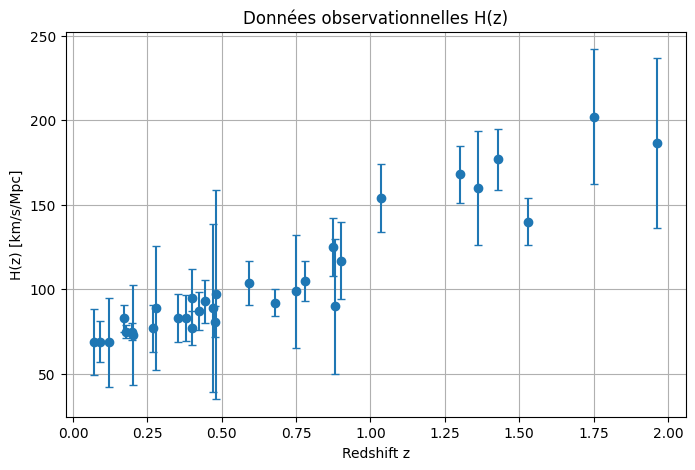

In [26]:
plt.figure()
plt.errorbar(
    hz_clean["z"],
    hz_clean["H"],
    yerr=hz_clean["sigma_H"],
    fmt="o",
    capsize=3
)
plt.xlabel("Redshift z")
plt.ylabel("H(z) [km/s/Mpc]")
plt.title("Données observationnelles H(z)")
plt.grid(True)
plt.show()

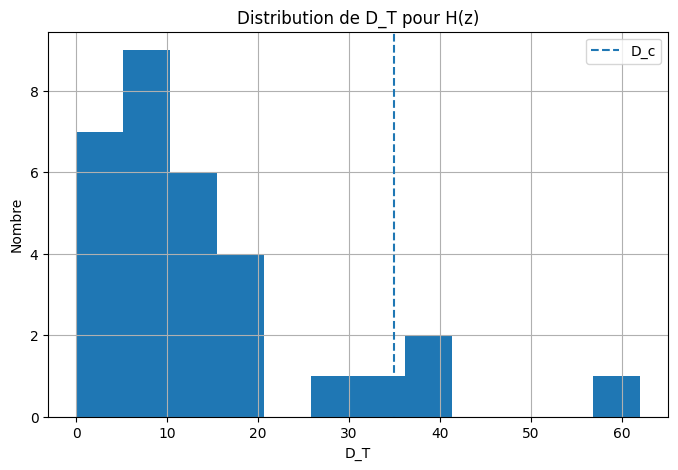

In [27]:
D_T_Hz = details_Hz["D_T"]

plt.figure()
plt.hist(D_T_Hz, bins=12)
plt.axvline(
    summary_Hz.loc[summary_Hz["Observable"] == "D_c", "Valeur"].values[0],
    linestyle="--",
    label="D_c"
)
plt.xlabel("D_T")
plt.ylabel("Nombre")
plt.title("Distribution de D_T pour H(z)")
plt.legend()
plt.grid(True)
plt.show()

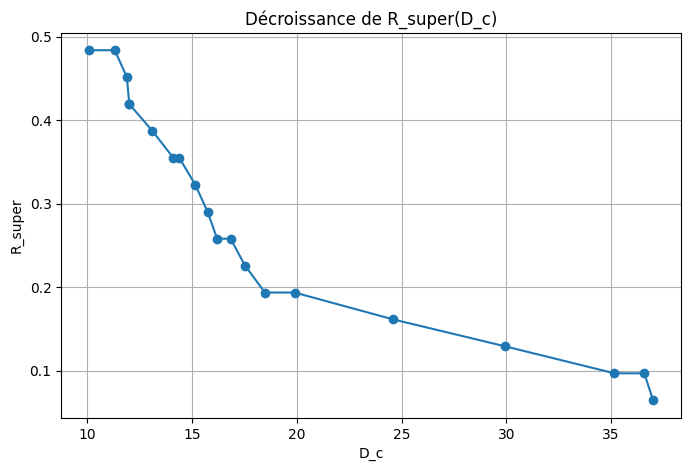

In [28]:
D_c_grid = details_Hz["D_c_grid"]
R_grid = details_Hz["R_super_grid"]

plt.figure()
plt.plot(D_c_grid, R_grid, "o-")
plt.xlabel("D_c")
plt.ylabel("R_super")
plt.title("Décroissance de R_super(D_c)")
plt.grid(True)
plt.show()

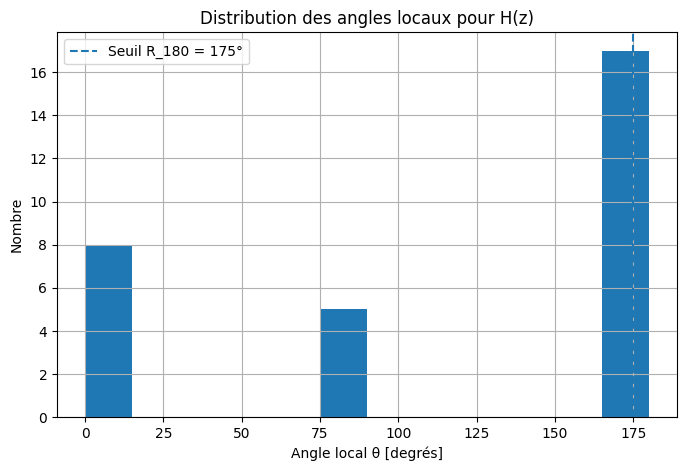

In [29]:
theta_Hz = details_Hz["theta"]

plt.figure()
plt.hist(theta_Hz, bins=12)
plt.axvline(175, linestyle="--", label="Seuil R_180 = 175°")
plt.xlabel("Angle local θ [degrés]")
plt.ylabel("Nombre")
plt.title("Distribution des angles locaux pour H(z)")
plt.legend()
plt.grid(True)
plt.show()

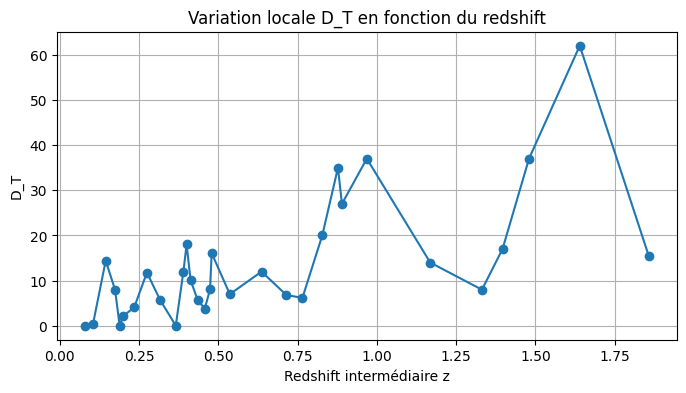

In [31]:
z_mid = 0.5 * (
    hz_clean["z"].values[:-1] + hz_clean["z"].values[1:]
)

D_T_Hz = details_Hz["D_T"]

plt.figure(figsize=(8,4))
plt.plot(z_mid, D_T_Hz, "o-")
plt.xlabel("Redshift intermédiaire z")
plt.ylabel("D_T")
plt.title("Variation locale D_T en fonction du redshift")
plt.grid(True)
plt.show()

## 7. Export des résultats

Les observables calculées sont exportées au format CSV afin de garantir la reproductibilité du pipeline et de faciliter leur réutilisation dans les analyses comparatives.

In [32]:
# ============================================================
# Export du tableau des observables
# ============================================================

summary_Hz.to_csv(
    "GVH_Hz_Observables.csv",
    index=False
)

print("Fichier exporté : GVH_Hz_Observables.csv")

Fichier exporté : GVH_Hz_Observables.csv


In [34]:
# ============================================================
# Export des détails du calcul
# ============================================================

details_df = pd.DataFrame({
    "D_T": pd.Series(details_Hz["D_T"]),
    "theta": pd.Series(details_Hz["theta"])
})

details_df.to_csv(
    "GVH_Hz_Details.csv",
    index=False
)

print("Fichier exporté : GVH_Hz_Details.csv")

Fichier exporté : GVH_Hz_Details.csv


In [35]:
import os

print(os.listdir())

['.config', 'GVH_Hz_Details.csv', 'HzTable_MM_BC32.txt', 'GVH_Hz_Observables.csv', 'HzTable_MM_BC32 (1).txt', 'drive', 'sample_data']


## 8. Conclusion

Le notebook **GVH_Hz_Pipeline_0.1** construit un ensemble reproductible d'observables GVH à partir d'une compilation de mesures observationnelles du paramètre de Hubble $begin:math:text$H\(z\)$end:math:text$.

Les observables calculées sont :

- $begin:math:text$D\_T$end:math:text$
- $begin:math:text$S\_T$end:math:text$
- $begin:math:text$S\_T\^\{\\rm norm\}$end:math:text$
- $begin:math:text$D\_c$end:math:text$
- $begin:math:text$R\_\{\\rm super\}$end:math:text$
- $begin:math:text$A\_H$end:math:text$
- $begin:math:text$B\_H$end:math:text$
- $begin:math:text$\\theta\_\{\\rm mean\}$end:math:text$
- $begin:math:text$\\theta\_\{\\max\}$end:math:text$
- $begin:math:text$R\_\{180\}$end:math:text$

Le pipeline applique les définitions mathématiques communes de **GVH Dynamic 0.1**, garantissant que les résultats obtenus sont directement comparables à ceux produits pour les autres jeux de données (Pantheon, BAO) et pour les systèmes dynamiques (Lorenz, Rössler et Duffing).

Cette version **0.1** est descriptive, reproductible et indépendante de toute interprétation physique spécifique. Les observables calculées constituent une base méthodologique pouvant être utilisée dans des analyses comparatives ultérieures.